# Week 5: Chat Template 对比 + Loss Masking 可视化

**目标**: 理解不同 chat template 的差异,可视化 loss masking 的效果。

In [1]:
import torch
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Arial Unicode MS']

## 1. 同一条对话,不同 Template 的对比

In [2]:
CONVERSATION = [
    {"role": "system", "content": "You are a helpful medical assistant."},
    {"role": "user", "content": "What are the symptoms of diabetes?"},
    {"role": "assistant", "content": "Common symptoms include increased thirst, frequent urination, and fatigue."},
]

tokenizers = {}
for name, model_id in [
    ("Qwen2.5", "Qwen/Qwen2.5-3B-Instruct"),
]:
    try:
        tokenizers[name] = AutoTokenizer.from_pretrained(model_id)
        print(f"{name} 加载成功")
    except Exception as e:
        print(f"{name} 加载失败: {e}")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Qwen2.5 加载成功


In [3]:
results = {}
for name, tok in tokenizers.items():
    prompt = tok.apply_chat_template(CONVERSATION, tokenize=False, add_generation_prompt=True)
    tokens = tok.encode(prompt)
    decoded = [tok.decode([t]) for t in tokens]
    results[name] = {
        'prompt': prompt,
        'tokens': tokens,
        'decoded': decoded,
        'count': len(tokens),
    }
    print(f"\n{'='*60}")
    print(f"Model: {name}")
    print(f"Token count: {len(tokens)}")
    print(f"Preview:\n{prompt[:300]}")
    print(f"\nFirst 30 tokens: {tokens[:30]}")
    print(f"Decoded: {''.join(decoded[:30])}")


Model: Qwen2.5
Token count: 45
Preview:
<|im_start|>system
You are a helpful medical assistant.<|im_end|>
<|im_start|>user
What are the symptoms of diabetes?<|im_end|>
<|im_start|>assistant
Common symptoms include increased thirst, frequent urination, and fatigue.<|im_end|>
<|im_start|>assistant


First 30 tokens: [151644, 8948, 198, 2610, 525, 264, 10950, 6457, 17847, 13, 151645, 198, 151644, 872, 198, 3838, 525, 279, 13495, 315, 19754, 30, 151645, 198, 151644, 77091, 198, 10839, 13495, 2924]
Decoded: <|im_start|>system
You are a helpful medical assistant.<|im_end|>
<|im_start|>user
What are the symptoms of diabetes?<|im_end|>
<|im_start|>assistant
Common symptoms include


## 2. 手动构造 ChatML 格式 vs apply_chat_template 对比

In [4]:
chatml_manual = (
    "<|im_start|>system\n"
    "You are a helpful medical assistant.<|im_end|>\n"
    "<|im_start|>user\n"
    "What are the symptoms of diabetes?<|im_end|>\n"
    "<|im_start|>assistant\n"
    "Common symptoms include increased thirst, frequent urination, and fatigue.<|im_end|>"
)

print("手动构造的 ChatML:")
print(chatml_manual)
print()

im_start_count = chatml_manual.count("<|im_start|>")
im_end_count = chatml_manual.count("<|im_end|>")
print(f"<|im_start|>: {im_start_count} 次")
print(f"<|im_end|>: {im_end_count} 次")

if 'Qwen2.5' in tokenizers:
    tok = tokenizers['Qwen2.5']
    api_prompt = tok.apply_chat_template(CONVERSATION, tokenize=False, add_generation_prompt=False)
    print(f"\napply_chat_template 输出:")
    print(api_prompt)
    print(f"\n手动 vs API 是否一致: {chatml_manual == api_prompt}")

手动构造的 ChatML:
<|im_start|>system
You are a helpful medical assistant.<|im_end|>
<|im_start|>user
What are the symptoms of diabetes?<|im_end|>
<|im_start|>assistant
Common symptoms include increased thirst, frequent urination, and fatigue.<|im_end|>

<|im_start|>: 3 次
<|im_end|>: 3 次

apply_chat_template 输出:
<|im_start|>system
You are a helpful medical assistant.<|im_end|>
<|im_start|>user
What are the symptoms of diabetes?<|im_end|>
<|im_start|>assistant
Common symptoms include increased thirst, frequent urination, and fatigue.<|im_end|>


手动 vs API 是否一致: False


## 3. Loss Masking 可视化

哪些 token 参与 loss 计算（assistant response），哪些被 mask 掉（设为 -100）

使用 Qwen2.5 tokenizer:


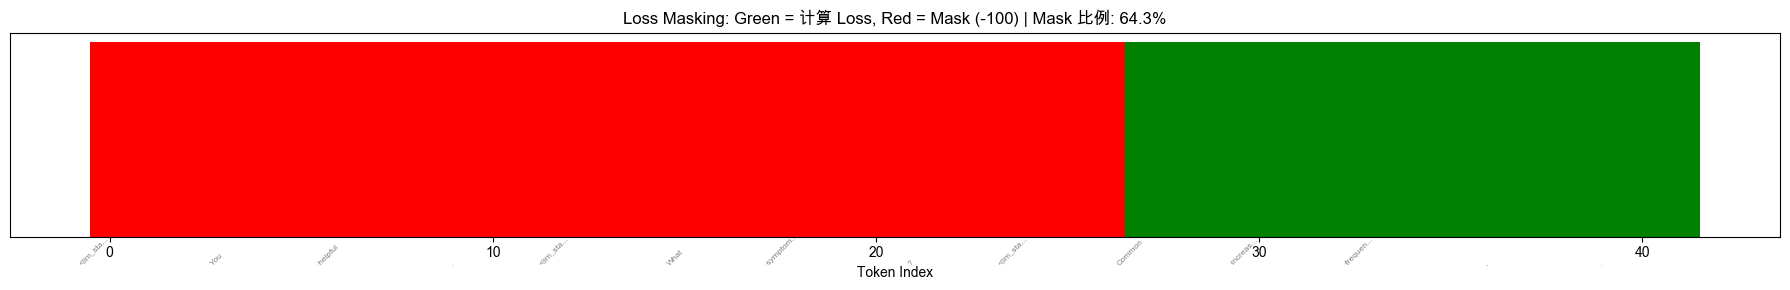

总 token 数: 42
参与 loss 的 token: 15 (35.7%)
被 mask 的 token: 27 (64.3%)

Loss masking 检查: mask 比例 > 50%? ✓ 正确


In [5]:
def mask_labels(input_ids, tokenizer):
    """只在最后一个 assistant 回复上计算 loss,其余设为 -100。"""
    labels = [-100] * len(input_ids)

    assistant_marker = tokenizer.encode("<|im_start|>assistant\n", add_special_tokens=False)
    marker_len = len(assistant_marker)

    last_assistant_start = -1
    for i in range(len(input_ids) - marker_len, -1, -1):
        if input_ids[i:i + marker_len] == assistant_marker:
            last_assistant_start = i
            break

    if last_assistant_start >= 0:
        for j in range(last_assistant_start + marker_len, len(input_ids)):
            labels[j] = input_ids[j]

    return labels


def visualize_loss_masking(tokenizer, conversation):
    prompt = tokenizer.apply_chat_template(conversation, tokenize=False)
    tokens = tokenizer.encode(prompt)
    labels = mask_labels(tokens, tokenizer)

    decoded = [tokenizer.decode([t]) for t in tokens]

    mask_ratio = sum(1 for l in labels if l == -100) / len(labels) * 100

    fig, ax = plt.subplots(figsize=(18, 3))
    colors = ['green' if l != -100 else 'red' for l in labels]
    ax.bar(range(len(tokens)), [1] * len(tokens), color=colors, width=1)
    ax.set_xlabel("Token Index")
    ax.set_yticks([])
    ax.set_title(f"Loss Masking: Green = 计算 Loss, Red = Mask (-100) | Mask 比例: {mask_ratio:.1f}%")

    for i, (t, d) in enumerate(zip(tokens, decoded)):
        clean = d.replace('\n', '\\n').replace(' ', '·')
        if len(clean) > 8:
            clean = clean[:8] + '...'
        if i % 3 == 0:
            ax.text(i, -0.15, clean, rotation=45, ha='right', fontsize=6, color='gray')

    plt.tight_layout()
    plt.show()

    n_loss = sum(1 for l in labels if l != -100)
    n_mask = sum(1 for l in labels if l == -100)
    print(f"总 token 数: {len(tokens)}")
    print(f"参与 loss 的 token: {n_loss} ({n_loss/len(tokens)*100:.1f}%)")
    print(f"被 mask 的 token: {n_mask} ({n_mask/len(tokens)*100:.1f}%)")
    print(f"\nLoss masking 检查: mask 比例 > 50%? {'✓ 正确' if mask_ratio > 50 else '✗ 异常'}")

if tokenizers:
    name = list(tokenizers.keys())[0]
    print(f"使用 {name} tokenizer:")
    visualize_loss_masking(tokenizers[name], CONVERSATION)

## 4. 多轮对话的 Loss Masking

使用 Qwen2.5 tokenizer:


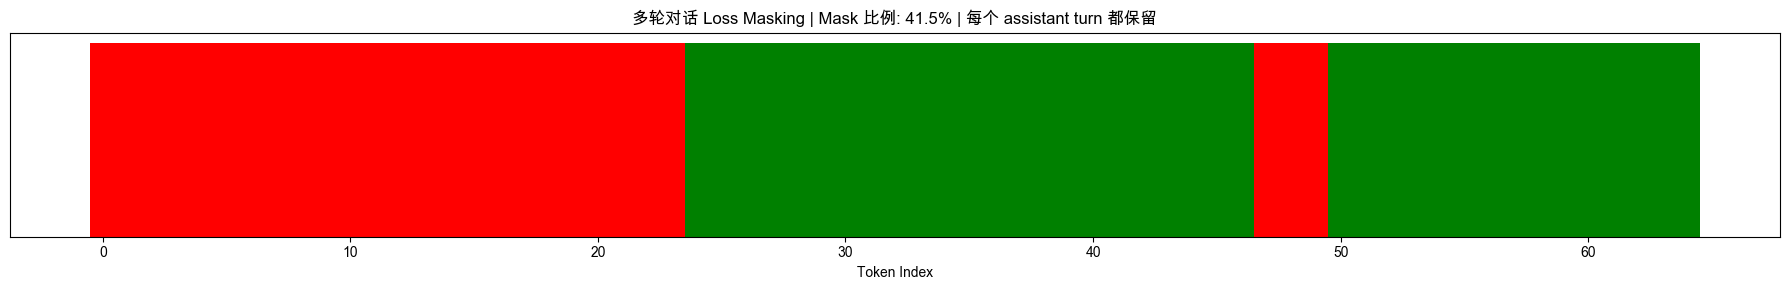

总 token 数: 65
参与 loss 的 token: 38 (58.5%)
被 mask 的 token: 27 (41.5%)


In [6]:
MULTI_TURN = [
    {"role": "system", "content": "You are a helpful medical assistant."},
    {"role": "user", "content": "What is diabetes?"},
    {"role": "assistant", "content": "Diabetes is a chronic condition affecting blood sugar regulation."},
    {"role": "user", "content": "What are the symptoms?"},
    {"role": "assistant", "content": "Common symptoms include increased thirst, frequent urination, and fatigue."},
]


def mask_labels_multi_turn(input_ids, tokenizer):
    """多轮对话: 每个 assistant turn 都参与 loss,其余 mask。"""
    labels = [-100] * len(input_ids)

    assistant_marker = tokenizer.encode("<|im_start|>assistant\n", add_special_tokens=False)
    marker_len = len(assistant_marker)

    assistant_positions = []
    for i in range(len(input_ids) - marker_len + 1):
        if input_ids[i:i + marker_len] == assistant_marker:
            assistant_positions.append(i)

    for pos in assistant_positions:
        start = pos + marker_len
        end = assistant_positions[assistant_positions.index(pos) + 1] if pos != assistant_positions[-1] else len(input_ids)
        for j in range(start, end):
            labels[j] = input_ids[j]

    return labels


def visualize_multi_turn_masking(tokenizer, conversation):
    prompt = tokenizer.apply_chat_template(conversation, tokenize=False)
    tokens = tokenizer.encode(prompt)
    labels = mask_labels_multi_turn(tokens, tokenizer)

    mask_ratio = sum(1 for l in labels if l == -100) / len(labels) * 100

    fig, ax = plt.subplots(figsize=(18, 3))
    colors = ['green' if l != -100 else 'red' for l in labels]
    ax.bar(range(len(tokens)), [1] * len(tokens), color=colors, width=1)
    ax.set_xlabel("Token Index")
    ax.set_yticks([])
    ax.set_title(f"多轮对话 Loss Masking | Mask 比例: {mask_ratio:.1f}% | 每个 assistant turn 都保留")
    plt.tight_layout()
    plt.show()

    n_loss = sum(1 for l in labels if l != -100)
    n_mask = sum(1 for l in labels if l == -100)
    print(f"总 token 数: {len(tokens)}")
    print(f"参与 loss 的 token: {n_loss} ({n_loss/len(tokens)*100:.1f}%)")
    print(f"被 mask 的 token: {n_mask} ({n_mask/len(tokens)*100:.1f}%)")

if tokenizers:
    name = list(tokenizers.keys())[0]
    print(f"使用 {name} tokenizer:")
    visualize_multi_turn_masking(tokenizers[name], MULTI_TURN)

## 5. Template 错配分析

In [7]:
print("=""=" * 40)
print("Chat Template 错配的后果分析")
print("=""=" * 40)
print()

scenarios = [
    {
        "场景": "用 Llama-3 template 训练 Qwen 模型",
        "原因": "Qwen 预训练时从未见过 <|begin_of_text|>, <|start_header_id|> 等 token",
        "后果": [
            "模型将这些 token 视为普通文本，无法区分角色边界",
            "推理时可能生成 Llama-3 风格的 token，但 Qwen 解码器无法正确处理",
            "训练 loss 可能正常下降，但实际效果极差（静默失败）",
        ],
    },
    {
        "场景": "用 Mistral template 训练 Qwen 模型",
        "原因": "Mistral 用 [INST]...[/INST] 格式，v0.2 没有 system role",
        "后果": [
            "system 指令被忽略或混入 user turn",
            "模型学不到 system prompt 的遵循能力",
            "角色边界模糊，可能产生重复或截断的输出",
        ],
    },
    {
        "场景": "训练时用 ChatML，推理时手写拼接",
        "原因": "手写拼接可能少一个换行、多一个空格",
        "后果": [
            "tokenize 结果与训练时不同",
            "模型在最熟悉的格式上表现最好，微小差异都会导致质量下降",
        ],
    },
]

for s in scenarios:
    print(f"\n{'─'*60}")
    print(f"场景: {s['场景']}")
    print(f"原因: {s['原因']}")
    print("后果:")
    for c in s['后果']:
        print(f"  - {c}")

print(f"\n{'='*60}")
print("结论: 始终用 tokenizer.apply_chat_template()，不要手写拼接")
print("训练和推理必须使用完全相同的 template")

Chat Template 错配的后果分析


────────────────────────────────────────────────────────────
场景: 用 Llama-3 template 训练 Qwen 模型
原因: Qwen 预训练时从未见过 <|begin_of_text|>, <|start_header_id|> 等 token
后果:
  - 模型将这些 token 视为普通文本，无法区分角色边界
  - 推理时可能生成 Llama-3 风格的 token，但 Qwen 解码器无法正确处理
  - 训练 loss 可能正常下降，但实际效果极差（静默失败）

────────────────────────────────────────────────────────────
场景: 用 Mistral template 训练 Qwen 模型
原因: Mistral 用 [INST]...[/INST] 格式，v0.2 没有 system role
后果:
  - system 指令被忽略或混入 user turn
  - 模型学不到 system prompt 的遵循能力
  - 角色边界模糊，可能产生重复或截断的输出

────────────────────────────────────────────────────────────
场景: 训练时用 ChatML，推理时手写拼接
原因: 手写拼接可能少一个换行、多一个空格
后果:
  - tokenize 结果与训练时不同
  - 模型在最熟悉的格式上表现最好，微小差异都会导致质量下降

结论: 始终用 tokenizer.apply_chat_template()，不要手写拼接
训练和推理必须使用完全相同的 template


---

**交付物**:
- ChatML 格式手动 vs API 对比
- Loss masking 可视化（单轮 + 多轮）
- Template 错配分析
- `loss_masking.py` 中的 `mask_labels` 实现